# Revision figures

Dataset composition for the revision, built from the merged release.

- **Figure A** - peptide-HLA pairs per allele across all 95 alleles, with the
  58 added in the revision distinguished from the 37 in the submitted dataset.
  Counted live from `metadata.csv`.

## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import wilcoxon

# Make the local utils package importable (project convention, see 01/07)
sys.path.insert(0, str(Path.cwd()))
from utils import set_plot_style

set_plot_style()

# === Figure sizing (Scientific Data conventions, matches 04_figure1_panels.ipynb) ===
MM = 1 / 25.4
COL1_WIDTH = 89 * MM    # ~3.5 in, single column
COL2_WIDTH = 183 * MM   # ~7.2 in, double column

plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "axes.linewidth":  0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

FIG_DIR = Path.cwd() / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    # Save a figure as PNG (300 dpi) + PDF into figures/, matching house style.
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300)
    fig.savefig(FIG_DIR / f"{name}.pdf")

COLOR_RELEASED = "#4477AA"   # blue, matches 01_structural_validation.ipynb palette
COLOR_NEW      = "#CC3311"   # red/orange accent, same palette
GRID_COLOR     = "#dddddd"

print(f"Figures will be written to: {FIG_DIR}")


Figures will be written to: <HOME>/main_project/scripts/IEDB_validation/figures


## Figure A - peptide-HLA pairs per allele

**Data source.** One file: `DATA_ROOT/huggingface/metadata.csv`, the merged
release. One peptide-HLA pair is one unique `(allele, peptide)` combination, all
released records included, the 15 flagged ones among them, matching how the
per-allele table in the manuscript is built.

An allele is drawn as *added in the revision* when it appears only under
`source_version == "v2"`. That column records the curation batch, so the split
is read from the release rather than reconstructed: 37 alleles were in the
submitted dataset, 58 more were added, 11 of them HLA-C.

This cell used to count HLA-C from `CLUSTER_ROOT/hlac_production/pdb/` and add
it to a 37-allele release. Those HLA-C pairs are now *in* metadata.csv, so
doing that would count them twice.

Uses the `allele` column (colon format, e.g. `B*35:03`), never `allele_iedb`
(underscore format, `HLA-B_35_03`); confusing the two has caused a real error
in this analysis before.


In [2]:
# --- Pairs per allele, counted live and read-only from the merged release ---
from paths import DATA_ROOT, MHC_DB_ROOT, CLUSTER_ROOT  # roots; override with PEPBIND3D_* env vars
METADATA_PATH = DATA_ROOT / "huggingface/metadata.csv"

metadata = pd.read_csv(METADATA_PATH, low_memory=False)
for _c in ("allele", "peptide", "source_version"):
    assert _c in metadata.columns, f"metadata.csv lacks {_c}"

pairs = metadata[["allele", "peptide", "source_version"]].drop_duplicates(
    subset=["allele", "peptide"])

submitted = set(metadata.loc[metadata["source_version"] == "v1", "allele"])
added = sorted(set(metadata["allele"]) - submitted)

pairs_per_allele = pairs.groupby("allele").size().sort_values(ascending=False)

print(f"metadata.csv: {len(metadata):,} rows, {metadata['allele'].nunique()} alleles")
print(f"  in the submitted dataset: {len(submitted)} alleles")
print(f"  added in the revision:    {len(added)} alleles "
      f"({sum(1 for a in added if a.startswith('C'))} HLA-C)")
print(f"  total pairs:              {pairs_per_allele.sum():,}")

assert len(pairs_per_allele) == metadata["allele"].nunique()


metadata.csv: 118,985 rows, 95 alleles
  in the submitted dataset: 37 alleles
  added in the revision:    58 alleles (11 HLA-C)
  total pairs:              112,561


In [3]:
# (The separate HLA-C count from the production PDB tree is gone: those pairs
# are in metadata.csv now, so counting them here as well would double them.)


Total alleles plotted: 95
Total pairs plotted:   112,561
Dynamic range:         1-10376


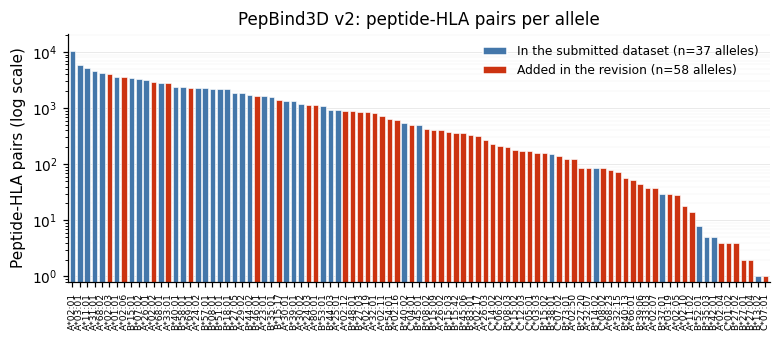

In [4]:
# --- Combine and plot ---
allele_counts = (pairs_per_allele.rename("pairs").reset_index()
                 .assign(is_new=lambda d: ~d["allele"].isin(submitted))
                 .sort_values("pairs", ascending=False).reset_index(drop=True))

print(f"Total alleles plotted: {len(allele_counts)}")
print(f"Total pairs plotted:   {allele_counts['pairs'].sum():,}")
print(f"Dynamic range:         {allele_counts['pairs'].min()}-{allele_counts['pairs'].max()}")

fig, ax = plt.subplots(figsize=(COL2_WIDTH, 3.2))

colors = [COLOR_NEW if is_new else COLOR_RELEASED for is_new in allele_counts["is_new"]]
x = np.arange(len(allele_counts))
ax.bar(x, allele_counts["pairs"], color=colors, edgecolor="white", linewidth=0.4, width=0.75)

# Dynamic range (1 to >9000) makes a linear axis useless -> log scale.
ax.set_yscale("log")
ax.set_ylim(0.8, allele_counts["pairs"].max() * 2)

ax.set_xticks(x)
ax.set_xticklabels(allele_counts["allele"], rotation=90, fontsize=6)
ax.set_xlim(-0.6, len(allele_counts) - 0.4)

ax.set_ylabel("Peptide-HLA pairs (log scale)")
ax.set_title("PepBind3D v2: peptide-HLA pairs per allele")

ax.yaxis.grid(True, which="major", color=GRID_COLOR, linewidth=0.5, alpha=0.8)
ax.yaxis.grid(True, which="minor", color=GRID_COLOR, linewidth=0.3, alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    Patch(facecolor=COLOR_RELEASED, edgecolor="white",
          label=f"In the submitted dataset (n={len(submitted)} alleles)"),
    Patch(facecolor=COLOR_NEW, edgecolor="white",
          label=f"Added in the revision (n={len(added)} alleles)"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=8, loc="upper right")

fig.tight_layout()
savefig(fig, "figureA_pairs_per_allele")
plt.show()
